In [1]:
import numpy as np
from SERGIO.GRN import grn_from_human,grn_from_networkx
from SERGIO._sergio import sergio
from SERGIO.MR import mrProfile
import pandas as pd
from SERGIO.GRN._grn import GRN
from SERGIO.GRN._components import Gene, SingleInteraction
import seaborn as sns
import matplotlib.pyplot as plt
%reload_ext autoreload
%autoreload 2

# Simulate GRN

Use regulatory network from Zhi-Ping Liu, Canglin Wu, Hongyu Miao and Hulin Wu (2015). RegNetwork: an integrated database of transcriptional and posttranscriptional regulatory networks in human and mouse. Database 2015. doi: [10.1093/database/bav095](10.1093/database/bav095)

In [65]:
networkx_grn = grn_from_human()
grn = grn_from_networkx(g=networkx_grn, parametrize=False)

/home/ml4ig1/Documents code/scPRINT/tools/SERGIO/SERGIO/GRN/_create.py:124: UserWarning: You want to sample 813 genes, but the full network contains 813. Sampling all genes available
  warnings.warn(


In [66]:
n = len(networkx_grn.nodes())
adj_matrix = np.zeros((n, n))
# Create a mapping of node names to integer indices
node_to_index = {node: idx for idx, node in enumerate(networkx_grn.nodes())}

# Populate the adjacency matrix using the node_to_index mapping
for u, v, data in networkx_grn.edges(data=True):
    u_idx = node_to_index[u]
    v_idx = node_to_index[v]
    adj_matrix[u_idx][v_idx] = data.get('weight', 0)

# Print the first few rows and columns of the adjacency matrix
print("Adjacency matrix (first 5x5):")
print(adj_matrix[:5, :5])

# Print the mapping for the first few nodes

Adjacency matrix (first 5x5):
[[0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [67]:
adj_matrix.shape

(813, 813)

In [33]:
(adj_matrix<0).sum()

30

In [34]:
(adj_matrix!=0).sum()

3546

In [68]:
mrs = grn.get_mrs()
mr_profs = mrProfile(MR_names = mrs, n_types = 1)
mr_profs.build_rnd(range_dict={'L': [1, 2.5], 'H': [3.5, 5]})


In [70]:
grn.init(mr_profs, update_half_resp = True)
sim = sergio(grn)
%time sim.simulate(nCells = 1000, noise_s = 1, safety_iter = 150, scale_iter = 10)

CPU times: user 23min 18s, sys: 2.18 s, total: 23min 21s
Wall time: 26min 23s


In [71]:
expr = sim.getSimExpr()

In [72]:
expr = expr.loc[list(node_to_index.keys())]

# Use custom graph from networkx

In [8]:
import networkx as nx

In [12]:
# create a networkx.DiGraph()
G = nx.DiGraph()
G.add_edges_from([('1','2',{'weight':2}),('2','3',{'weight':-1}),('3','1',{'weight':3})])# if weight is not given, grn_from_networkx will parametrize automatically

# convert the networkx.DiGraph() to a GRN object
grn = grn_from_networkx(g= G, parametrize=False)

In [13]:
mrs = grn.get_mrs()
mr_profs = mrProfile(MR_names = mrs, n_types = 2)
mr_profs.build_rnd(range_dict={'L': [1, 2.5], 'H': [3.5, 5]})
grn.init(mr_profs, update_half_resp = True)
sim = sergio(grn)
sim.simulate(nCells = 200, noise_s = 1, safety_iter = 150, scale_iter = 10)

In [47]:
expr = sim.getSimExpr()

In [23]:
a = set(A.edges())
a.add(1)#note that Sergio removes cycles

## Add Technical Noise _ Steady-State Simulations

In [73]:
"""
Add outlier genes
"""
expr = sim.outlier_effect(expr, outlier_prob = 0.01, mean = 0.8, scale = 1)

"""
Add Library Size Effect
"""
libFactor, expr = sim.lib_size_effect(expr, mean = 4.6, scale = 0.4)

"""
Add Dropouts
"""
binary_ind = sim.dropout_indicator(expr, shape = 6.5, percentile = 82)
expr = np.multiply(binary_ind, expr)

"""
Convert to UMI count
"""
expr = sim.convert_to_UMIcounts(expr)



In [74]:
from grnndata import GRNAnnData

In [75]:
grn = GRNAnnData(X=expr.T, grn=adj_matrix)
grn.var_names=list(node_to_index.keys())

In [76]:
grn.write_h5ad('sergio_gt_grn.h5ad')

(array([7.58437e+05, 4.16060e+04, 7.27300e+03, 1.31500e+03, 2.62000e+02,
        8.40000e+01, 1.40000e+01, 5.00000e+00, 3.00000e+00, 1.00000e+00]),
 array([0. , 0.9, 1.8, 2.7, 3.6, 4.5, 5.4, 6.3, 7.2, 8.1, 9. ]),
 <BarContainer object of 10 artists>)

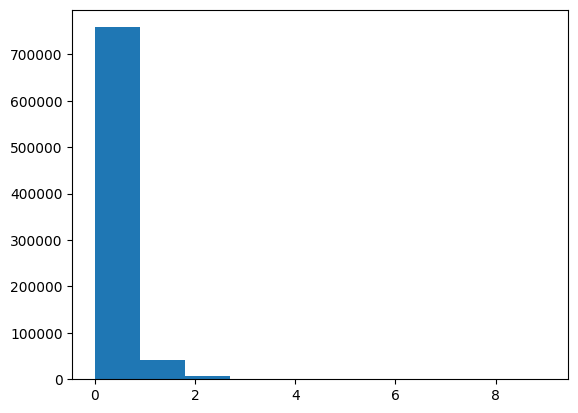

In [14]:
plt.hist(expr.ravel())

# Simulate perturbation
In the following, we perturb nodes that have a successor, and we measure the effect of perturbation.

In [6]:
from SERGIO._perturbation import Perturbation

select production rate for nodes perturbed with crispri and crispra. The idea is that
`basal_prod_crispri`$\ll$`basal_prod_crispra ` should be a small number, while


In [8]:
pert = Perturbation()
pert.initialise_parameters(grn,basal_prod_crispri = 0.2,basal_prod_crispra = 7)#select production rate for nodes perturbed with crispri and crispra.

INFO:SERGIO._perturbation:Number of nodes will be perturbed is 43


In [9]:
%time pert.perturbation_all(nCells=10)
#pert.save()

CPU times: user 28.8 s, sys: 652 ms, total: 29.4 s
Wall time: 35.8 s


Now it has been generated `pert.crispri_data`,`pert.crispra_data` and `pert.wt`, which contains perturbation and wild type information.
`pert.crispri_data` is structured as follows:
- dimension 0 describes the index target gene
- dimension 1 describe the index of genes whose expression is measured
- dimension 2 describes the index of cell

`pert.wt` is structured as follows:
- dimension 0 describe the index of genes whose expression is measured
- dimension 1 describes the index of cell

The name of gene perturbed can be found from `nodes_2perturb`, and  the gene measured from `pert.gNames_`

In [6]:
pert.crispri_data.shape,pert.wt.shape

((54, 412, 10), (412, 10))

visualise the effect of perturbation

Text(0.5, 1.0, 'Expression of node 4286')

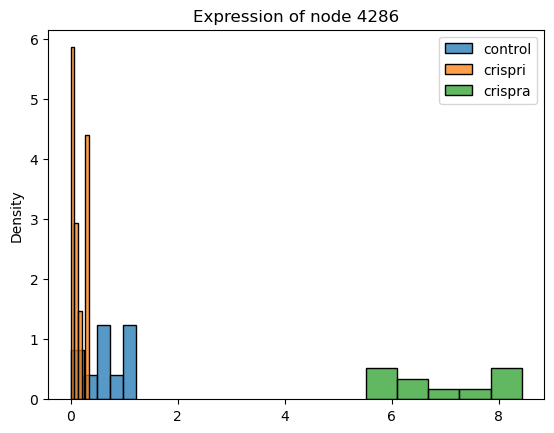

In [15]:

node_perturb = pert.nodes_2perturb[1]#take the first element for demostration, you can take any element you like
index_expr = pert.gNames_.index(node_perturb)#take the index of the node for the expression dimension
sns.histplot(pert.wt[index_expr],label = 'control',stat = 'density')
sns.histplot(pert.crispri_data[pert.nodes_2perturb == node_perturb,index_expr][0],label = 'crispri',stat = 'density')
sns.histplot(pert.crispra_data[pert.nodes_2perturb == node_perturb,index_expr][0],label = 'crispra',stat = 'density')
plt.legend()
plt.title('Expression of node '+node_perturb)

Text(0.5, 1.0, 'Expression of node 4842')

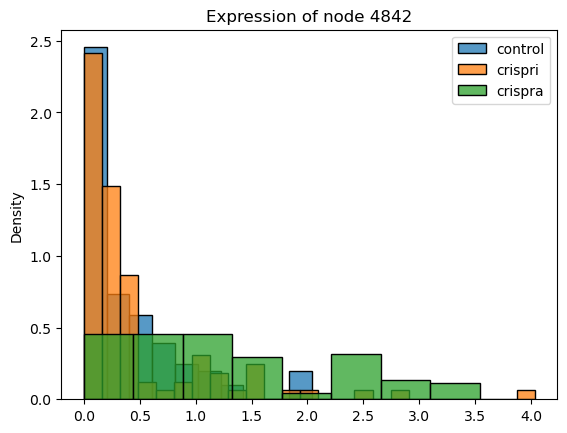

In [16]:
G = pert.grn_.to_networkx()
node_perturb,node_expr = list(G.edges())[0]#take a pair of gene interacting
index_expr = pert.gNames_.index(node_expr)#take the index of the node for the expression dimension
sns.histplot(pert.wt[index_expr],label = 'control',stat = 'density')
sns.histplot(pert.crispri_data[pert.nodes_2perturb == node_perturb,index_expr][0],label = 'crispri',stat = 'density')
sns.histplot(pert.crispra_data[pert.nodes_2perturb == node_perturb,index_expr][0],label = 'crispra',stat = 'density')
plt.legend()
plt.title('Expression of node '+node_expr)

In [16]:
wt,crispri,crispra = pert.technical_noise()

In [12]:
pert.data_path

'SERGIO/data'

In [11]:
pert.save()

In [14]:
pert = perturbation()
pert = pert.load(43,10)

In [ ]:
pert.grn_